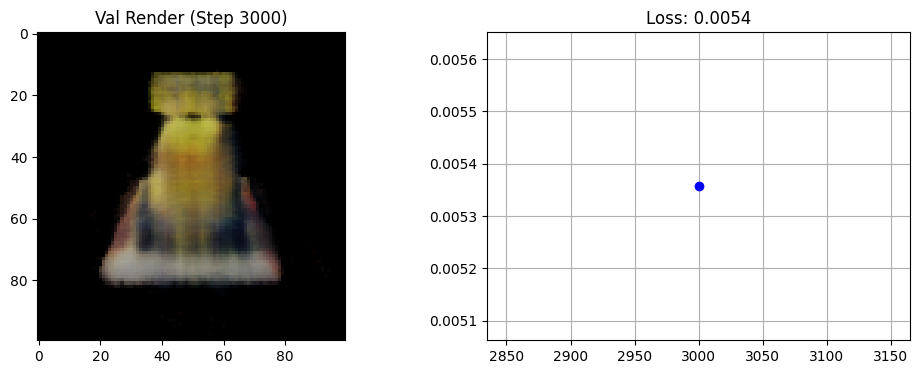

Training complete!


In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset
import os
from IPython.display import clear_output

# ======================
# 1. Data Preparation
# ======================
print("Downloading dataset...")
!wget -q http://cseweb.ucsd.edu/~viscomp/projects/LF/papers/ECCV20/nerf/tiny_nerf_data.npz

class NeRFDataset(Dataset):
    def __init__(self, data_path, split='train'):
        data = np.load(data_path)
        self.images = torch.tensor(data['images'][:100]).float()
        self.poses = torch.tensor(data['poses'][:100]).float()
        self.focal = float(data['focal'])
        self.H, self.W = self.images.shape[1:3]

        # Train/val split
        val_idx = np.linspace(0, len(self.images)-1, 10).astype(int)
        mask = np.ones(len(self.images), bool)
        mask[val_idx] = 0
        if split == 'train':
            self.images = self.images[mask]
            self.poses = self.poses[mask]
        else:
            self.images = self.images[~mask]
            self.poses = self.poses[~mask]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return {'image': self.images[idx], 'pose': self.poses[idx]}

# ======================
# 2. Enhanced NeRF Model
# ======================
class EnhancedNeRF(nn.Module):
    def __init__(self, L_pos=10):
        super().__init__()
        self.L_pos = L_pos
        input_dim = 3 + 3 * 2 * L_pos

        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 4)
        )

        # Initialize weights
        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)

    def positional_encoding(self, x):
        encodings = [x]
        for i in range(self.L_pos):
            encodings.append(torch.sin(2**i * x))
            encodings.append(torch.cos(2**i * x))
        return torch.cat(encodings, dim=-1)

    def forward(self, x):
        x_encoded = self.positional_encoding(x)
        return self.net(x_encoded)

# ======================
# 3. Fixed Rendering
# ======================
def render_rays(model, rays_o, rays_d, near=2, far=6, N_samples=64):
    # Sample points along rays
    t_vals = torch.linspace(near, far, N_samples, device=rays_o.device)
    pts = rays_o[:,None,:] + rays_d[:,None,:] * t_vals[None,:,None]  # [B, N, 3]

    # Flatten for network
    pts_flat = pts.reshape(-1, 3)
    raw = model(pts_flat)
    rgb = torch.sigmoid(raw[:,:3]).view(*pts.shape)  # [B, N, 3]
    sigma = torch.relu(raw[:,3]).view(pts.shape[:-1])  # [B, N]

    # Volume rendering (fixed)
    dists = t_vals[1:] - t_vals[:-1]  # [N-1]
    dists = torch.cat([dists, torch.tensor([1e10], device=dists.device)])  # [N]

    alpha = 1 - torch.exp(-sigma * dists)  # [B, N]
    weights = alpha * torch.cumprod(1 - alpha + 1e-10, dim=-1)  # [B, N]

    rgb_map = (weights[...,None] * rgb).sum(dim=1)  # [B, 3]
    return rgb_map, weights

# ======================
# 4. Training Loop
# ======================
def train():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Load data
    train_dataset = NeRFDataset('tiny_nerf_data.npz', 'train')
    val_dataset = NeRFDataset('tiny_nerf_data.npz', 'val')
    focal = train_dataset.focal

    # Model
    model = EnhancedNeRF().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=500, gamma=0.8)

    os.makedirs('progress', exist_ok=True)

    for step in range(3001):
        # Sample batch
        data = train_dataset[np.random.randint(len(train_dataset))]
        image = data['image'].to(device)  # [H, W, 3]
        pose = data['pose'].to(device)    # [4, 4]

        # Sample random pixels
        H, W = image.shape[:2]
        rand_h = torch.randint(0, H, (1024,))
        rand_w = torch.randint(0, W, (1024,))
        target = image[rand_h, rand_w]    # [1024, 3]

        # Generate rays
        ray_o = pose[:3, 3]              # [3]
        pixel_coords = torch.stack([
            (rand_w - W/2) / focal,
            -(rand_h - H/2) / focal,
            -torch.ones_like(rand_w)
        ], dim=-1).to(device)            # [1024, 3]
        ray_d = torch.matmul(pixel_coords, pose[:3, :3].T)  # [1024, 3]
        ray_d = ray_d / torch.norm(ray_d, dim=-1, keepdim=True)

        # Render
        pred, weights = render_rays(model, ray_o.expand(1024, -1), ray_d)

        # Loss
        loss = ((pred - target)**2).mean()
        sparsity_loss = 0.01 * torch.mean(weights)
        total_loss = loss + sparsity_loss

        # Optimize
        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()
        scheduler.step()

        # Validation
        if step % 100 == 0:
            with torch.no_grad():
                val_data = val_dataset[0]
                val_image = val_data['image'].to(device)
                val_pose = val_data['pose'].to(device)

                # Render full validation image
                h, w = torch.meshgrid(torch.arange(H), torch.arange(W))
                coords = torch.stack([
                    (w - W/2) / focal,
                    -(h - H/2) / focal,
                    -torch.ones(H, W)
                ], dim=-1).to(device)
                ray_d_val = torch.matmul(coords, val_pose[:3,:3].T)
                ray_d_val = ray_d_val / torch.norm(ray_d_val, dim=-1, keepdim=True)

                # Render in chunks to avoid OOM
                chunk = 1024
                val_pred = torch.zeros(H, W, 3, device=device)
                for i in range(0, H*W, chunk):
                    rays_d_chunk = ray_d_val.view(-1, 3)[i:i+chunk]
                    pred_chunk, _ = render_rays(model,
                                              val_pose[:3,3].expand(len(rays_d_chunk), -1),
                                              rays_d_chunk)
                    val_pred.view(-1, 3)[i:i+chunk] = pred_chunk

            clear_output(wait=True)
            fig, ax = plt.subplots(1, 2, figsize=(12, 4))
            ax[0].imshow(val_pred.cpu())
            ax[0].set_title(f'Val Render (Step {step})')
            ax[1].plot(step, loss.item(), 'bo')
            ax[1].set_title(f'Loss: {loss.item():.4f}')
            ax[1].grid(True)
            plt.show()

# ======================
# 5. Run Training
# ======================
print("Starting training...")
train()
print("Training complete!")